# 07 — Marker positivity

Identify the cells positive for one marker, on one donor, from that donor's own distribution.

Full cell population, no subsampling, no clipping. No Otsu, no RESTORE divisor, no input floor,
and no assumption about how many cells should be positive.

**Set the two parameters below and run top to bottom.** The last step writes a CSV you can import
into QuPath to look at the called cells on the image.


In [1]:
# ---- PARAMETERS -------------------------------------------------------------
DONOR  = '6566'
MARKER = 'INS'
# -----------------------------------------------------------------------------
import sys, glob, pathlib, warnings
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d
warnings.filterwarnings('ignore')
REPO = pathlib.Path.cwd().resolve().parents[1]
sys.path.insert(0, str(pathlib.Path.cwd().parent))
CELLS = REPO/'data'/'cells_redsea'      # REDSEA spillover-corrected whole-cell means
print('donor', DONOR, '| marker', MARKER, '|', CELLS)


donor 6566 | marker INS | /home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/data/cells_redsea


## 1 — Load every cell for this donor


In [2]:
f = glob.glob(str(CELLS/f'donor_id={DONOR}'/'*.parquet'))[0]
col = pd.read_parquet(f, columns=['object_id', MARKER])
v = col[MARKER].to_numpy(float)
ok = np.isfinite(v) & (v >= 0)
col, v = col[ok].reset_index(drop=True), v[ok]
print(f'{len(v):,} cells   median {np.median(v):.1f}   max {v.max():.1f}')


1,781,276 cells   median 10.0   max 9526.8


## 2 — The distribution

Log scale. The dim bulk and the bright positive population should be visibly separate.


In [3]:
pos = v[v > 0]
lv = np.log10(pos)
h, e = np.histogram(lv, bins=60, range=(lv.min(), lv.max()))
for i in range(len(h)):
    print(f'{10**e[i]:9.1f} - {10**e[i+1]:9.1f} | {h[i]:9,} ' + '#'*int(60*h[i]/max(h.max(),1)))


      0.0 -       0.0 |         2 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         2 
      0.0 -       0.0 |         0 
      0.0 -       0.0 |         3 
      0.0 -       0.0 |         1 
      0.0 -       0.0 |         4 
      0.0 -       0.0 |         2 
      0.0 -       0.0 |         8 
      0.0 -       0.0 |         7 
      0.0 -       0.0 |        15 
      0.0 -       0.0 |        11 
      0.0 -       0.0 |        20 
      0.0 -       0.0 |        33 
      0.0 -       0.0 |        40 
      0.0 -       0.0 |        52 
      0.0 -       0.0 |        85 
      0.0 -       0.0 |       142 
      0.0 -       0.0 |       189 
      0.0 -       0.0 |       234 
      0.0 -       0.0 |       376 
      0.0 -       0.0 |       547 
      0.0 -       0.0 |       734 
      0.0 -       0.0 |     1,017 
      0.0 -       0.1 |     1,365 
      0.1 -       0.1 |     1,840 
      0.1 -       0.1 |     2,608 
      0.1 -       0.

## 3 — Find the boundary

The two populations are separated by a **gap**, so find it as one: locate the bulk's peak, then
walk right to the first local minimum in the smoothed density.

`depth` is the only knob — how far below the bulk peak the minimum must fall to count as the
boundary. Lower it if the call is too permissive, raise it if too strict.


In [4]:
def find_boundary(values, bins=160, smooth=7, depth=0.02):
    """Boundary between the dim bulk and the bright population, from this donor's own histogram."""
    p = values[values > 0]
    lp = np.log10(p)
    hh, ee = np.histogram(lp, bins=bins, range=(lp.min(), lp.max()))
    c = 0.5*(ee[:-1]+ee[1:])
    s = uniform_filter1d(hh.astype(float), size=smooth)
    mode = int(np.argmax(s))
    for i in range(mode+3, len(s)-3):
        if s[i] <= s[i-1] and s[i] <= s[i+1] and s[i] < depth*s[mode]:
            return 10**c[i], dict(mode=10**c[mode], centers=c, smooth=s, mode_i=mode, anti_i=i)
    return np.nan, dict(mode=10**c[mode], centers=c, smooth=s, mode_i=mode, anti_i=None)

DEPTH = 0.02
thr, dg = find_boundary(v, depth=DEPTH)
is_pos = v > thr
print(f'bulk peak  : {MARKER} ~ {dg["mode"]:.1f}')
print(f'boundary   : {MARKER} ~ {thr:.1f}')
print(f'positive   : {is_pos.sum():,} cells  ({is_pos.mean()*100:.4f}% of {len(v):,})')


bulk peak  : INS ~ 11.9
boundary   : INS ~ 219.5
positive   : 933 cells  (0.0524% of 1,781,276)


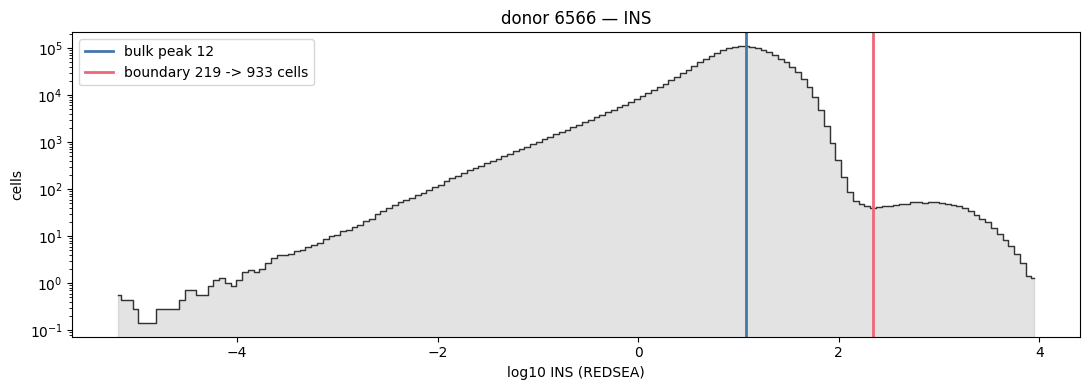

In [5]:
fig, ax = plt.subplots(figsize=(11,4))
ax.step(dg['centers'], dg['smooth'], where='mid', color='#333', lw=1)
ax.fill_between(dg['centers'], dg['smooth'], step='mid', alpha=.2, color='#777')
ax.axvline(np.log10(dg['mode']), color='#4477AA', lw=2, label=f'bulk peak {dg["mode"]:.0f}')
if np.isfinite(thr):
    ax.axvline(np.log10(thr), color='#EE6677', lw=2, label=f'boundary {thr:.0f} -> {is_pos.sum():,} cells')
ax.set_yscale('log'); ax.set_xlabel(f'log10 {MARKER} (REDSEA)'); ax.set_ylabel('cells')
ax.set_title(f'donor {DONOR} — {MARKER}'); ax.legend(); plt.tight_layout(); plt.show()


## 4 — Look at the calls in QuPath

Writes `object_id` + call for every cell. Import with `scripts/groovy/import_broad_lineage.groovy`
(it matches on the QuPath detection UUID, which is `object_id`) and compare against the channel.

**This is the check that matters.** Everything above is the donor's own histogram; only the image
says whether the call is right.


In [6]:
outdir = REPO/'data'/'positivity'/f'{MARKER}'
outdir.mkdir(parents=True, exist_ok=True)
out = pd.DataFrame({'object_id': col['object_id'].astype(str),
                    MARKER: v,
                    f'{MARKER}_pos': is_pos})
dst = outdir/f'{MARKER}_{DONOR}.csv'
out.to_csv(dst, index=False)
print(f'{dst}   {is_pos.sum():,} positive of {len(out):,}')
out[out[f'{MARKER}_pos']].head()


/home/smith6jt/IO60panc2nd/Islet-Explorer-Senior/data/positivity/INS/INS_6566.csv   933 positive of 1,781,276


,object_id,INS,INS_pos
8703,3c058e87-f897-413a-a3b6-22e7914ea88f,3568.756842,True
8708,a60b13ba-0f0a-442a-86dd-9e7cabe1e1d2,1266.019663,True
8711,7215de5e-bbcc-4b4e-b2ec-b30d6c45219f,220.078363,True
8715,049f538c-a97a-40e1-9175-ff3e2e11fbcb,266.254687,True
8717,7beb3a8b-158f-48c6-95dc-13609af7b4d7,527.826671,True


## 5 — Every donor

The boundary should land in a similar intensity band on each donor — it is the same biological
edge. The **count** is free to vary, because that is the biology.


In [7]:
rows = []
for p in sorted(glob.glob(str(CELLS/'donor_id=*'))):
    dn = p.split('donor_id=')[1]
    c2 = pd.read_parquet(glob.glob(p+'/*.parquet')[0], columns=[MARKER])[MARKER].to_numpy(float)
    c2 = c2[np.isfinite(c2) & (c2 >= 0)]
    t, g = find_boundary(c2, depth=DEPTH)
    n = int((c2 > t).sum()) if np.isfinite(t) else -1
    rows.append(dict(donor=dn, n_cells=len(c2), bulk_peak=round(g['mode'],1),
                     boundary=round(t,1) if np.isfinite(t) else np.nan,
                     n_positive=n, pct=round(n/len(c2)*100,4) if n>=0 else np.nan))
    print(f"  {dn}: {n:>8,} positive   boundary {rows[-1]['boundary']}", flush=True)
summary = pd.DataFrame(rows)
summary


  115:   48,224 positive   boundary 324.6


  6374:   50,284 positive   boundary 480.2


  6380:       12 positive   boundary 239.5


  6436:    2,087 positive   boundary 182.9


  6442:   19,831 positive   boundary 240.9


...

  6566:      933 positive   boundary 219.5


  6591:    6,424 positive   boundary 573.4


  6593:   20,633 positive   boundary 197.9


  6623:       59 positive   boundary 254.4


,donor,n_cells,bulk_peak,boundary,n_positive,pct
0,115,860864,26.5,324.6,48224,5.6018
1,6374,2132190,34.0,480.2,50284,2.3583
2,6380,623782,8.4,239.5,12,0.0019
3,6436,1579443,3.6,182.9,2087,0.1321
4,6442,1419677,6.0,240.9,19831,1.3969
5,6450,368048,5.8,165.1,1991,0.5410
6,6461,1445032,6.3,370.6,29263,2.0251
7,6476,1625350,32.0,356.4,50821,3.1268
8,6482,1135669,22.9,467.9,31152,2.7431
9,6493,1227411,13.5,458.4,36106,2.9416


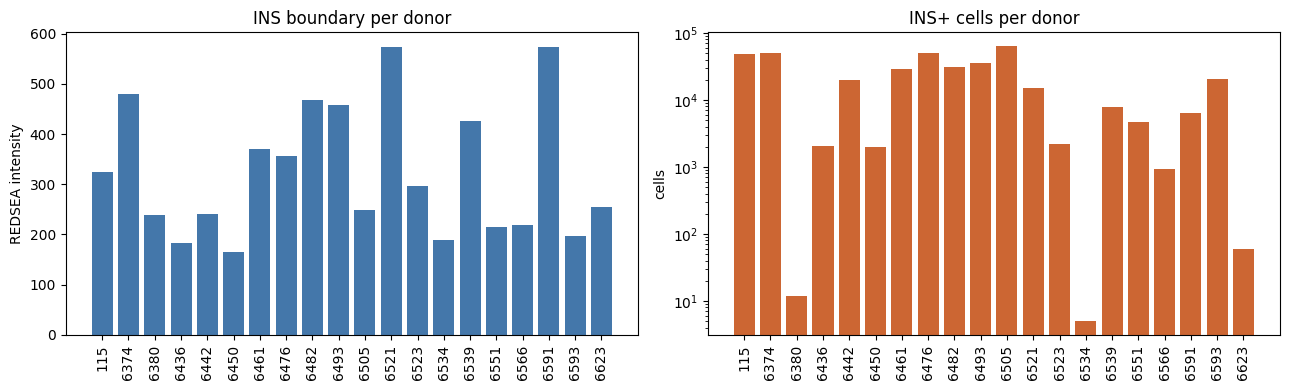

In [8]:
fig, ax = plt.subplots(1,2, figsize=(13,4))
ax[0].bar(summary.donor, summary.boundary, color='#4477AA')
ax[0].set_title(f'{MARKER} boundary per donor'); ax[0].set_ylabel('REDSEA intensity')
ax[0].tick_params(axis='x', rotation=90)
ax[1].bar(summary.donor, summary.n_positive.clip(lower=1), color='#CC6633'); ax[1].set_yscale('log')
ax[1].set_title(f'{MARKER}+ cells per donor'); ax[1].set_ylabel('cells')
ax[1].tick_params(axis='x', rotation=90)
plt.tight_layout(); plt.show()
